# **Veri setini hazırlama**

In [1]:
# ============================================================
# 1) LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import os
import gc
from google.colab import files

CSV_NAME = "cleaned_reviews.csv"
DATA_DIR = "data"
DATASET_NAME = "rmisra/imdb-spoiler-dataset"

# ============================================================
# 2) VERI HAZIRLAMA MOTORU
# ============================================================

def prepare_data():
    print("🔄 Veri Hazırlama Başladı...")

    # ------------------------------------------------------------
    # SENARYO 1: Temizlenmiş CSV zaten varsa
    # ------------------------------------------------------------
    if os.path.exists(CSV_NAME):
        print(f"✅ '{CSV_NAME}' bulundu. Doğrudan yükleniyor...")
        df = pd.read_csv(CSV_NAME)
        df["clean_text"] = df["clean_text"].fillna("")
        print(f"🚀 Veri Hazır! Toplam {len(df)} yorum.")
        return df

    # ------------------------------------------------------------
    # SENARYO 2: Ham veri yoksa Kaggle’dan indir
    # ------------------------------------------------------------
    if not os.path.exists(f"{DATA_DIR}/IMDB_reviews.json"):
        print("⚠️ Ham veri bulunamadı. Kaggle indirme başlatılıyor...")

        try:
            import kaggle
        except:
            !pip install kaggle -q

        # Kaggle.json kontrolü
        if not os.path.exists("/root/.kaggle/kaggle.json"):
            print("❗ Kaggle API anahtarı yok. Lütfen kaggle.json yükleyin:")
            uploaded = files.upload()
            if "kaggle.json" not in uploaded:
                raise ValueError("⛔ kaggle.json yüklenmedi!")

            !mkdir -p ~/.kaggle
            !mv kaggle.json ~/.kaggle/
            !chmod 600 ~/.kaggle/kaggle.json

        print("📥 Dataset indiriliyor...")
        !kaggle datasets download -d rmisra/imdb-spoiler-dataset --force -q

        print("📦 Zip açılıyor...")
        !unzip -o imdb-spoiler-dataset.zip -d data > /dev/null

    # ------------------------------------------------------------
    # SENARYO 3: JSON dosyalarını yükle + birleştir + temizle
    # ------------------------------------------------------------
    print("📚 JSON dosyaları yükleniyor...")

    try:
        df_reviews = pd.read_json(f"{DATA_DIR}/IMDB_reviews.json", lines=True)
        df_details = pd.read_json(f"{DATA_DIR}/IMDB_movie_details.json", lines=True)
    except:
        print("⚠️ RAM tasarruflu yükleme moduna geçildi...")
        df_reviews = pd.concat(pd.read_json(
            f"{DATA_DIR}/IMDB_reviews.json", lines=True, chunksize=150000
        ))
        df_details = pd.read_json(f"{DATA_DIR}/IMDB_movie_details.json", lines=True)

    print("🔗 DataFrame birleştiriliyor...")
    df = df_reviews.merge(df_details[["movie_id"]], on="movie_id", how="left")

    del df_reviews, df_details
    gc.collect()

    # ------------------------------------------------------------
    # METİN TEMİZLEME
    # ------------------------------------------------------------
    print("🧹 Metin temizliği yapılıyor...")

    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r"<.*?>", " ", text)
        text = re.sub(r"http\\S+", " ", text)
        text = re.sub(r"\\s+", " ", text).strip()
        return text

    df["clean_text"] = df["review_text"].apply(clean_text)
    df = df[df["clean_text"].str.len() > 20]
    df.drop(columns=["review_text"], inplace=True)

    # ------------------------------------------------------------
    # FILM BAZLI TRAIN/VAL/TEST SPLIT
    # ------------------------------------------------------------
    print("✂️ Film bazlı train/val/test split yapılıyor...")

    movie_ids = df["movie_id"].unique()
    np.random.seed(42)
    np.random.shuffle(movie_ids)

    n = len(movie_ids)
    train_ids, val_ids, test_ids = np.split(movie_ids, [int(0.7*n), int(0.85*n)])

    df["split"] = "train"
    df.loc[df["movie_id"].isin(val_ids), "split"] = "val"
    df.loc[df["movie_id"].isin(test_ids), "split"] = "test"

    # ------------------------------------------------------------
    # CSV KAYDET
    # ------------------------------------------------------------
    print(f"💾 '{CSV_NAME}' kaydediliyor...")
    df.to_csv(CSV_NAME, index=False)

    print(f"🎉 Veri Hazır! Toplam {len(df)} yorum.")
    return df


# ============================================================
# ÇALIŞTIR
# ============================================================

df = prepare_data()

print("\n📌 Veri Seti Özeti:")
print(df["split"].value_counts())
df.head(3)[["clean_text", "is_spoiler", "split"]]


🔄 Veri Hazırlama Başladı...
⚠️ Ham veri bulunamadı. Kaggle indirme başlatılıyor...
❗ Kaggle API anahtarı yok. Lütfen kaggle.json yükleyin:


Saving kaggle.json to kaggle.json
📥 Dataset indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/rmisra/imdb-spoiler-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
📦 Zip açılıyor...
📚 JSON dosyaları yükleniyor...
🔗 DataFrame birleştiriliyor...
🧹 Metin temizliği yapılıyor...
✂️ Film bazlı train/val/test split yapılıyor...
💾 'cleaned_reviews.csv' kaydediliyor...
🎉 Veri Hazır! Toplam 573910 yorum.

📌 Veri Seti Özeti:
split
train    406834
test      84273
val       82803
Name: count, dtype: int64


,clean_text,is_spoiler,split
0,"in its oscar year, shawshank redemption (writt...",True,train
1,the shawshank redemption is without a doubt on...,True,train
2,i believe that this film is the best story eve...,True,train


# **İlk deneme**

1. Setting up environment and downloading data...
Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rmisra/imdb-spoiler-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 99% 327M/331M [00:00<00:00, 1.72GB/s]
100% 331M/331M [00:00<00:00, 1.71GB/s]
Archive:  imdb-spoiler-dataset.zip
  inflating: data/IMDB_movie_details.json  
  inflating: data/IMDB_reviews.json  
Loading JSON files...
Data loaded. Total reviews: 573913

2. Cleaning text...

3. Splitting data (Train/Test by Movie ID)...
Train Size: 406828
Test Size : 84271

4. Vectorizing text (TF-IDF)...

5. Training Logistic Regression Model...
Model trained.

6. Evaluating Model...

Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.75      0.80     62403
        True       0.47      0.64      0.54     21868

    accuracy                           0.72     84271
   macro avg       0.66      0.69      0.67     84271
weighted avg       0.76      0.72      0.73     84271

ROC-AUC Score: 0.

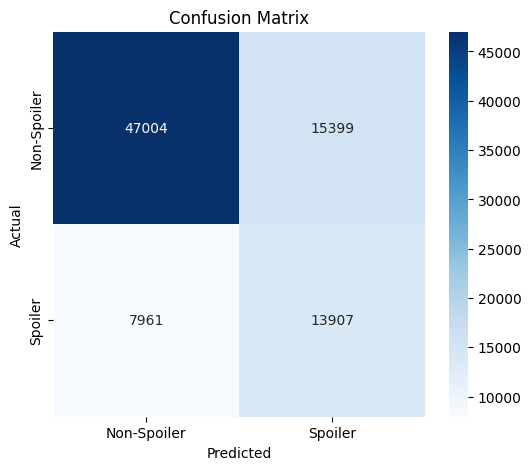


7. Top Words Indicating Spoilers:
                word       coef
8429        spoilers  18.860718
8427         spoiler  17.416971
2365            dies   6.934888
7908        score 10   4.765548
2363            died   4.748360
4929          killed   4.710862
4935           kills   4.192280
8430  spoilers ahead   4.083410
8428   spoiler alert   3.996380
391            alert   3.938170

Top Words Indicating Non-Spoilers:
               word      coef
2563           dont -3.588081
3869          grade -3.176577
1594         cliche -3.025513
8425          spoil -2.857184
9588           vote -2.656882
848   beginning end -2.222780
2544       don miss -2.194335
3738    giving away -2.192356
3413     filmmaking -2.165503
1127         brazil -2.097916


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- STEP 1: Download & Load Data ---
print("1. Setting up environment and downloading data...")

# Install Kaggle library
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

if 'kaggle.json' in uploaded:
    # Move kaggle.json to the correct location
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    # Download Dataset
    print("Downloading dataset from Kaggle...")
    !kaggle datasets download -d rmisra/imdb-spoiler-dataset --force
    !unzip -o imdb-spoiler-dataset.zip -d data

    # Load JSON files
    print("Loading JSON files...")
    try:
        df_reviews = pd.read_json("data/IMDB_reviews.json", lines=True)
        df_details = pd.read_json("data/IMDB_movie_details.json", lines=True)

        # Merge reviews with movie details (to get movie_id for splitting)
        df = df_reviews.merge(df_details[['movie_id']], on='movie_id', how='left')
        print(f"Data loaded. Total reviews: {len(df)}")

    except ValueError as e:
        print(f"Error loading JSON: {e}")
        # Fallback for some json line errors if any
        df = None
else:
    print("kaggle.json not uploaded. Cannot proceed with download.")
    df = None

if df is not None:
    # --- STEP 2: Preprocessing ---
    print("\n2. Cleaning text...")

    # Basic text cleaning function
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'<.*?>', ' ', text)  # HTML tags
        text = re.sub(r'http\S+', ' ', text) # URLs
        text = re.sub(r'\s+', ' ', text).strip() # Extra spaces
        return text

    df['clean_text'] = df['review_text'].apply(clean_text)

    # Filter short reviews
    df = df[df['clean_text'].str.split().str.len() > 5]

    # --- STEP 3: Train/Test Split (Movie-based) ---
    print("\n3. Splitting data (Train/Test by Movie ID)...")

    movie_ids = df['movie_id'].unique()
    np.random.seed(42)
    np.random.shuffle(movie_ids)

    # 70% Train, 15% Val, 15% Test
    n = len(movie_ids)
    train_movies, val_movies, test_movies = np.split(movie_ids, [int(.7*n), int(.85*n)])

    # Create split column
    df['split'] = 'train'
    df.loc[df['movie_id'].isin(val_movies), 'split'] = 'val'
    df.loc[df['movie_id'].isin(test_movies), 'split'] = 'test'

    # Separate dataframes
    train_df = df[df['split'] == 'train']
    test_df = df[df['split'] == 'test']

    X_train = train_df['clean_text'].astype(str)
    y_train = train_df['is_spoiler']
    X_test = test_df['clean_text'].astype(str)
    y_test = test_df['is_spoiler']

    print(f"Train Size: {len(X_train)}")
    print(f"Test Size : {len(X_test)}")

    # --- STEP 4: TF-IDF Vectorization ---
    print("\n4. Vectorizing text (TF-IDF)...")

    tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 3), stop_words='english')
# max_features'i 5000'den 10000'e çıkardık, kelime dağarcığı genişledi.

    # Fit only on training data to avoid leakage
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # --- STEP 5: Model Training ---
    print("\n5. Training Logistic Regression Model...")

    # Class weight 'balanced' handles the imbalance between spoiler/non-spoiler
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train_tfidf, y_train)
    print("Model trained.")

    # --- STEP 6: Evaluation ---
    print("\n6. Evaluating Model...")

    y_pred = model.predict(X_test_tfidf)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    roc_score = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score: {roc_score:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Spoiler', 'Spoiler'],
                yticklabels=['Non-Spoiler', 'Spoiler'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # --- STEP 7: Feature Importance ---
    print("\n7. Top Words Indicating Spoilers:")
    feature_names = tfidf.get_feature_names_out()
    coefs = model.coef_[0]

    feat_df = pd.DataFrame({'word': feature_names, 'coef': coefs})
    # Top positive coefficients -> Spoilers
    print(feat_df.sort_values(by='coef', ascending=False).head(10))

    print("\nTop Words Indicating Non-Spoilers:")
    # Top negative coefficients -> Non-Spoilers
    print(feat_df.sort_values(by='coef', ascending=True).head(10))

else:
    print("Data processing skipped due to missing data.")

Model, TRAIN + VALIDATION setlerinin birleşimiyle (C=1) yeniden eğitiliyor...
Eski Eğitim Seti Boyutu : 406828
Yeni Eğitim Seti Boyutu : 489627 (Daha fazla veri!)

NİHAİ MODEL SONUÇLARI (Train + Val)
              precision    recall  f1-score   support

       False       0.86      0.75      0.80     62403
        True       0.47      0.64      0.55     21868

    accuracy                           0.72     84271
   macro avg       0.67      0.70      0.67     84271
weighted avg       0.76      0.72      0.73     84271

ROC-AUC Skoru: 0.7676


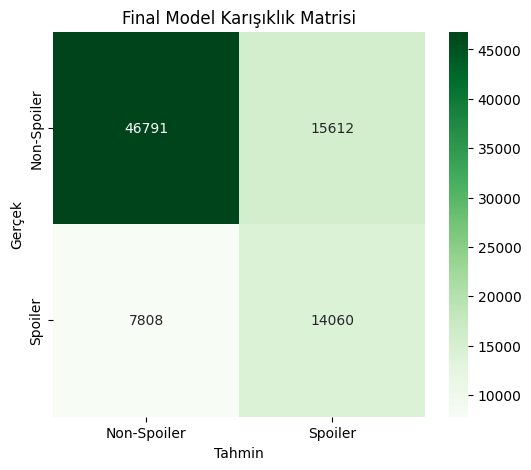

In [ ]:
from scipy.sparse import vstack

# 1. En iyi C değerini belirle (Önceki adımdan C=1 bulmuştuk, onu kullanıyoruz)
best_C = 1

print(f"Model, TRAIN + VALIDATION setlerinin birleşimiyle (C={best_C}) yeniden eğitiliyor...")

# 2. Verileri Birleştir (Train ve Validation setlerini alt alta ekle)
# TF-IDF matrisleri seyrek (sparse) matris olduğu için 'vstack' kullanıyoruz
X_train_full = vstack([X_train_tfidf, X_val_tfidf])
y_train_full = pd.concat([y_train, y_val])

print(f"Eski Eğitim Seti Boyutu : {X_train_tfidf.shape[0]}")
print(f"Yeni Eğitim Seti Boyutu : {X_train_full.shape[0]} (Daha fazla veri!)")

# 3. Final Modeli Eğit (Daha fazla veri ile)
final_model = LogisticRegression(C=best_C, class_weight='balanced', max_iter=1000, random_state=42)
final_model.fit(X_train_full, y_train_full)

# 4. Test Setinde Son Kez Dene
y_pred_final = final_model.predict(X_test_tfidf)
y_prob_final = final_model.predict_proba(X_test_tfidf)[:, 1]

# Sonuçları Göster
print("\n" + "="*40)
print("NİHAİ MODEL SONUÇLARI (Train + Val)")
print("="*40)
print(classification_report(y_test, y_pred_final))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_prob_final):.4f}")

# Yeni Karışıklık Matrisi
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Farklı olması için Yeşil yaptık
            xticklabels=['Non-Spoiler', 'Spoiler'],
            yticklabels=['Non-Spoiler', 'Spoiler'])
plt.title('Final Model Karışıklık Matrisi')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

# **En iyi C değerlerini bulma**

In [ ]:
# Denenecek C değerleri
c_values = [0.01, 0.1, 1, 10, 100]

print("Tüm C değerleri için DETAYLI VALIDATION sonuçları:\n")

for c in c_values:
    print("="*60)
    print(f"C DEĞERİ: {c}")
    print("="*60)

    # 1. Modeli bu C değeriyle kur
    model = LogisticRegression(C=c, class_weight='balanced', max_iter=1000, random_state=42)

    # 2. Sadece TRAIN verisiyle eğit
    model.fit(X_train_tfidf, y_train)

    # 3. VALIDATION verisi üzerinde test et
    y_pred_val = model.predict(X_val_tfidf)

    # 4. Raporu yazdır
    print(classification_report(y_val, y_pred_val))
    print("-" * 60 + "\n")

Tüm C değerleri için DETAYLI VALIDATION sonuçları:

C DEĞERİ: 0.01
              precision    recall  f1-score   support

       False       0.86      0.71      0.78     61391
        True       0.44      0.65      0.53     21408

    accuracy                           0.70     82799
   macro avg       0.65      0.68      0.65     82799
weighted avg       0.75      0.70      0.71     82799

------------------------------------------------------------

C DEĞERİ: 0.1
              precision    recall  f1-score   support

       False       0.86      0.75      0.80     61391
        True       0.47      0.65      0.54     21408

    accuracy                           0.72     82799
   macro avg       0.66      0.70      0.67     82799
weighted avg       0.76      0.72      0.73     82799

------------------------------------------------------------

C DEĞERİ: 1
              precision    recall  f1-score   support

       False       0.86      0.76      0.80     61391
        True       0

# **Kelime sayısını 10k yaptık**

✅ Veri zaten hafızada, işleme devam ediliyor.
Veri setleri ayrıştırılıyor...

TF-IDF işlemi yapılıyor (Kelime Haznesi: 10.000)...
Eğitim verileri birleştiriliyor...
Model eğitiliyor (Genişletilmiş Kelime Haznesi ile)...
Test yapılıyor...

MODEL SONUÇLARI (10.000 Kelime ile)
              precision    recall  f1-score   support

       False       0.86      0.75      0.80     62403
        True       0.47      0.64      0.55     21868

    accuracy                           0.72     84271
   macro avg       0.67      0.70      0.67     84271
weighted avg       0.76      0.72      0.73     84271

ROC-AUC Skoru: 0.7674


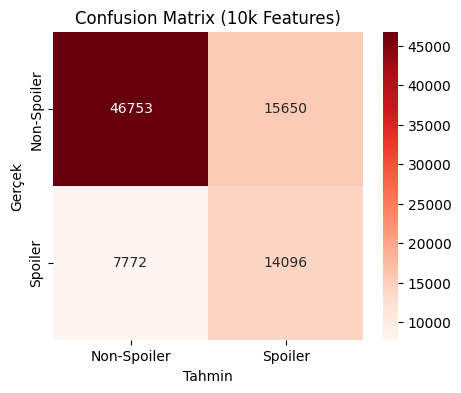

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.sparse import vstack

# --- ADIM 1: Veriyi Kontrol Et ve Yükle ---
try:
    # Eğer df hafızadaysa tekrar yüklemeye gerek yok, yoksa dosyadan oku
    if 'df' not in locals():
        df = pd.read_csv('cleaned_reviews.csv')
        df['clean_text'] = df['clean_text'].fillna("")
        print("✅ Veri dosyadan yüklendi.")
    else:
        print("✅ Veri zaten hafızada, işleme devam ediliyor.")
except FileNotFoundError:
    print("❌ HATA: Veri bulunamadı. Lütfen en baştaki veri hazırlama kodunu çalıştırın.")

# --- ADIM 2: Veriyi Parçala ---
print("Veri setleri ayrıştırılıyor...")
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

y_train = train_df['is_spoiler']
y_val = val_df['is_spoiler']
y_test = test_df['is_spoiler']

X_train = train_df['clean_text'].astype(str)
X_val = val_df['clean_text'].astype(str)
X_test = test_df['clean_text'].astype(str)

# --- ADIM 3: TF-IDF (GÜNCELLENEN KISIM) ---
print("\nTF-IDF işlemi yapılıyor (Kelime Haznesi: 10.000)...")

# BURASI DEĞİŞTİ: max_features=10000 yaptık
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')

# Train setine göre öğren
X_train_tfidf = tfidf.fit_transform(X_train)
# Diğerlerini dönüştür
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# --- ADIM 4: Verileri Birleştir (Train + Val) ---
print("Eğitim verileri birleştiriliyor...")
X_train_full = vstack([X_train_tfidf, X_val_tfidf])
y_train_full = pd.concat([y_train, y_val])

# --- ADIM 5: Modeli Eğit ---
# En iyi C değerini 1 olarak bulmuştuk, onu kullanıyoruz
print("Model eğitiliyor (Genişletilmiş Kelime Haznesi ile)...")
model = LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_full, y_train_full)

# --- ADIM 6: Sonuçları Gör ---
print("Test yapılıyor...")
y_pred = model.predict(X_test_tfidf)
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

print("\n" + "="*50)
print("MODEL SONUÇLARI (10.000 Kelime ile)")
print("="*50)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")

# Karışıklık Matrisi
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Non-Spoiler', 'Spoiler'],
            yticklabels=['Non-Spoiler', 'Spoiler'])
plt.title('Confusion Matrix (10k Features)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

# **Max_features=15k ve Ngram=1,4**

🚀 Gelişmiş Lojistik Regresyon (V2) Eğitiliyor...
Metinler sayıya çevriliyor (Trigramlar + 15.000 Özellik)...
Lojistik Regresyon modeli eğitiliyor...
Test seti üzerinde tahmin yapılıyor...

LOJİSTİK REGRESYON (GELİŞMİŞ) SONUÇLARI
              precision    recall  f1-score   support

       False       0.86      0.75      0.80     62403
        True       0.48      0.64      0.55     21868

    accuracy                           0.72     84271
   macro avg       0.67      0.70      0.67     84271
weighted avg       0.76      0.72      0.74     84271



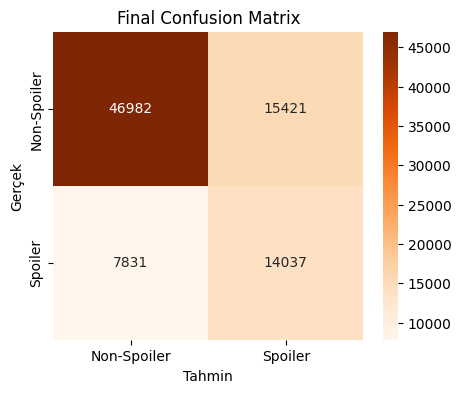


Modelin En Çok Dikkat Ettiği Kelimeler/Kalıplar:
               kelime    katsayı
12701        spoilers  17.195353
12699         spoiler  16.049106
3517              dir   8.533908
3473             dies   6.746379
12702  spoilers ahead   5.745802
7423           killed   5.068886
11956        score 10   4.954229
3471             died   4.215546
4158              end   4.214649
7430            kills   3.945660


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import vstack
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Gelişmiş Lojistik Regresyon (V2) Eğitiliyor...")

# --- ADIM 1: Daha Güçlü TF-IDF ---
print("Metinler sayıya çevriliyor (Ngram=1,4 + 15.000 Özellik)...")

# ngram_range=(1, 4): 4 kelimelik öbekleri de (örn: "hero dies at end") yakalayacak.
# max_features=15000: Modelin kelime dağarcığını %50 artırdık.
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 4), stop_words='english')

# Verileri Dönüştür
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# --- ADIM 2: Verileri Birleştir (Train + Val) ---
# Modeli mümkün olan en fazla veriyle besliyoruz
X_train_full = vstack([X_train_tfidf, X_val_tfidf])
y_train_full = pd.concat([y_train, y_val])

# --- ADIM 3: Modeli Eğit ---
print("Lojistik Regresyon modeli eğitiliyor...")
# C=1 değeri en dengeli sonuçtu, onu koruyoruz.
model = LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_full, y_train_full)

# --- ADIM 4: Test Et ---
print("Test seti üzerinde tahmin yapılıyor...")
y_pred = model.predict(X_test_tfidf)

print("\n" + "="*50)
print("LOJİSTİK REGRESYON (GELİŞMİŞ) SONUÇLARI")
print("="*50)
print(classification_report(y_test, y_pred))

# Görselleştirme
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Spoiler', 'Spoiler'],
            yticklabels=['Non-Spoiler', 'Spoiler'])
plt.title('Final Confusion Matrix')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

# En Belirleyici YENİ Kalıplar
feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]
feature_importance = pd.DataFrame({'kelime': feature_names, 'katsayı': coefs})
print("\nModelin En Çok Dikkat Ettiği Kelimeler/Kalıplar:")
print(feature_importance.sort_values(by='katsayı', ascending=False).head(10))

# **En iyi parametreleri bulma**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("🚀 Hızlandırılmış Grid Search Başlıyor...")

# --- ADIM 1: Veriyi Örnekle (Sadece Hız İçin) ---
# En iyi ayarları bulmak için 400.000 satırın hepsine gerek yok.
# Rastgele 50.000 yorum seçiyoruz. Bu, doğru ayarları bulmak için yeterlidir.
sample_size = 50000
train_sample = train_df.sample(n=sample_size, random_state=42)

X_sample = train_sample['clean_text'].astype(str)
y_sample = train_sample['is_spoiler']

print(f"Grid Search için {len(X_train)} yerine {len(X_sample)} satırlık örneklem kullanılıyor.")

# --- ADIM 2: Pipeline ve Ayarlar ---
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

parameters = {
    'tfidf__max_features': [5000, 10000, 15000],
    'tfidf__ngram_range': [(1, 2), (1, 3),(1,4)],
    'tfidf__min_df': [2, 5],
    'clf__C': 0.1,
}

# --- ADIM 3: Hızlı Arama ---
# n_jobs=-1 yapabiliriz çünkü veri azaldığı için RAM patlamaz.
grid_search = GridSearchCV(pipeline, parameters, cv=3, scoring='f1', n_jobs=-1, verbose=1)

print("Arama başladı...")
grid_search.fit(X_sample, y_sample)

print(f"\n✅ En İyi Parametreler Bulundu: {grid_search.best_params_}")

# --- ADIM 4: ASIL EĞİTİM (Tüm Veri ile) ---
print("\nBulunan en iyi ayarlarla TÜM VERİ (Train) eğitiliyor...")

# En iyi parametreleri alıp yeni, temiz bir model kuruyoruz
best_params = grid_search.best_params_

final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=best_params['tfidf__max_features'],
        ngram_range=best_params['tfidf__ngram_range'],
        min_df=best_params['tfidf__min_df']
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=best_params['clf__C']
    ))
])

# Şimdi modeli TÜM eğitim verisiyle eğitiyoruz
final_pipeline.fit(X_train, y_train)

# --- ADIM 5: Final Testi ---
print("\nTest seti üzerinde değerlendirme...")
y_pred_best = final_pipeline.predict(X_test)

print("\n" + "="*50)
print("OPTİMİZE EDİLMİŞ FİNAL MODEL SONUCU")
print("="*50)
print(classification_report(y_test, y_pred_best))

🚀 Hızlandırılmış Grid Search Başlıyor...
Grid Search için 406828 yerine 50000 satırlık örneklem kullanılıyor.
Arama başladı...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ En İyi Parametreler Bulundu: {'clf__C': 1, 'tfidf__max_features': 15000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}

Bulunan en iyi ayarlarla TÜM VERİ (Train) eğitiliyor...

Test seti üzerinde değerlendirme...

OPTİMİZE EDİLMİŞ FİNAL MODEL SONUCU
              precision    recall  f1-score   support

       False       0.85      0.76      0.80     62403
        True       0.48      0.63      0.54     21868

    accuracy                           0.72     84271
   macro avg       0.67      0.69      0.67     84271
weighted avg       0.76      0.72      0.74     84271



# **Optimal parametreler + en iyi regularizasyon değeri olarak C=0.1**

1. Veri seti kontrol ediliyor...
✅ Veri hafızada mevcut, devam ediliyor.

2. Veri setleri ayrıştırılıyor...

3. Metinler vektörleştiriliyor (Trigrams + 15.000 Özellik)...
Eğitim verileri (Train + Validation) birleştiriliyor...

4. En iyi Regularizasyon (C) değeri aranıyor ve model eğitiliyor...
   (Bu işlem 3-5 dakika sürebilir, lütfen bekleyin...)

✅ En İyi Regularizasyon Değeri (C) Bulundu: 0.1

5. Final Testi Yapılıyor...

REGULARİZE EDİLMİŞ MODEL SONUÇLARI (C=0.1)
              precision    recall  f1-score   support

       False       0.86      0.74      0.80     62403
        True       0.47      0.65      0.55     21868

    accuracy                           0.72     84271
   macro avg       0.66      0.70      0.67     84271
weighted avg       0.76      0.72      0.73     84271

ROC-AUC Skoru: 0.7682


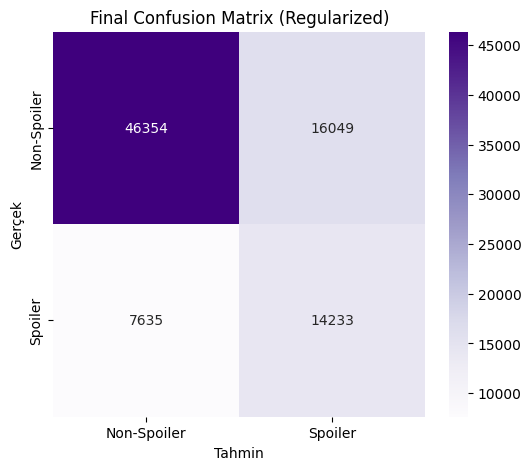

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV  # Otomatik Regularizasyon için
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.sparse import vstack

# --- ADIM 1: Veri Kontrolü ve Yükleme ---
print("1. Veri seti kontrol ediliyor...")
try:
    if 'df' not in locals():
        df = pd.read_csv('cleaned_reviews.csv')
        df['clean_text'] = df['clean_text'].fillna("")
        print("✅ Veri dosyadan yüklendi.")
    else:
        print("✅ Veri hafızada mevcut, devam ediliyor.")
except FileNotFoundError:
    print("❌ HATA: Veri bulunamadı. Lütfen veri hazırlama kodunu çalıştırın.")

# --- ADIM 2: Veri Ayrıştırma ---
print("\n2. Veri setleri ayrıştırılıyor...")
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

y_train = train_df['is_spoiler']
y_val = val_df['is_spoiler']
y_test = test_df['is_spoiler']

X_train = train_df['clean_text'].astype(str)
X_val = val_df['clean_text'].astype(str)
X_test = test_df['clean_text'].astype(str)

# --- ADIM 3: Gelişmiş TF-IDF (15k Kelime + 3'lü Gruplar) ---
print("\n3. Metinler vektörleştiriliyor (Trigrams + 15.000 Özellik)...")
# (1, 4) çok yavaş olduğu için (1, 3) ideal dengedir.
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 3), stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# --- ADIM 4: Veri Birleştirme ---
print("Eğitim verileri (Train + Validation) birleştiriliyor...")
X_train_full = vstack([X_train_tfidf, X_val_tfidf])
y_train_full = pd.concat([y_train, y_val])

# --- ADIM 5: Otomatik Regularizasyonlu Model Eğitimi ---
print("\n4. En iyi Regularizasyon (C) değeri aranıyor ve model eğitiliyor...")
print("   (Bu işlem 3-5 dakika sürebilir, lütfen bekleyin...)")

# LogisticRegressionCV: En iyi C değerini kendisi deneyerek bulur.
# Cs: Denenecek C değerleri listesi.
# cv=3: 3 katlı doğrulama yaparak en sağlam C değerini seçer.
model_cv = LogisticRegressionCV(
    Cs=[0.01, 0.1, 1, 5, 10],  # Denenecek Regularizasyon Şiddetleri
    cv=3,                      # Hız için 3 katlı doğrulama yeterli
    class_weight='balanced',   # Dengesiz veri için
    max_iter=1000,
    random_state=42,
    n_jobs=-1                  # Tüm işlemcileri kullan (Hız için)
)

model_cv.fit(X_train_full, y_train_full)

print(f"\n✅ En İyi Regularizasyon Değeri (C) Bulundu: {model_cv.C_[0]}")

# --- ADIM 6: Test ve Sonuçlar ---
print("\n5. Final Testi Yapılıyor...")
y_pred = model_cv.predict(X_test_tfidf)
y_prob = model_cv.predict_proba(X_test_tfidf)[:, 1]

print("\n" + "="*50)
print(f"REGULARİZE EDİLMİŞ MODEL SONUÇLARI (C={model_cv.C_[0]})")
print("="*50)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")

# Karışıklık Matrisi
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-Spoiler', 'Spoiler'],
            yticklabels=['Non-Spoiler', 'Spoiler'])
plt.title('Final Confusion Matrix (Regularized)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

# tüm veri seti ile en iyi regularizasyon ve parametre değerleri

In [ ]:
import pandas as pd
import numpy as np
import re
import gc # RAM temizliği için
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from scipy.sparse import vstack

print("🚀 TAM KAPASİTE (FULL DATA) EĞİTİM BAŞLIYOR (Grafiksiz Versiyon)...")

# --- ADIM 1: Veriyi Yükle ---
print("1. Tüm veri seti yükleniyor...")

try:
    # Veriyi parça parça değil, tamamını okuyoruz
    df_reviews = pd.read_json("data/IMDB_reviews.json", lines=True)
    df_details = pd.read_json("data/IMDB_movie_details.json", lines=True)

    # Birleştirme
    df = df_reviews.merge(df_details[['movie_id']], on='movie_id', how='left')

    # Gereksizleri silip RAM'i rahatlat
    del df_reviews
    del df_details
    gc.collect()

    print(f"✅ Başarıyla yüklendi! Toplam Yorum: {len(df)}")

    # --- ADIM 2: Metin Temizliği ---
    print("\n2. Metinler temizleniyor...")

    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r'<.*?>', ' ', text)
        text = re.sub(r'http\S+', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['clean_text'] = df['review_text'].apply(clean_text)

    # Çok kısa yorumları at
    df = df[df['clean_text'].str.len() > 20]

    # Orijinal metni sil (RAM tasarrufu)
    df.drop(columns=['review_text'], inplace=True)
    gc.collect()

    # --- ADIM 3: Veri Ayırma (Train/Val/Test) ---
    print("\n3. Veri seti filmlere göre ayrıştırılıyor...")
    movie_ids = df['movie_id'].unique()
    np.random.seed(42)
    np.random.shuffle(movie_ids)

    # %70 Train, %15 Val, %15 Test
    n = len(movie_ids)
    train_m, val_m, test_m = np.split(movie_ids, [int(.7*n), int(.85*n)])

    # Etiketle
    df['split'] = 'train'
    df.loc[df['movie_id'].isin(val_m), 'split'] = 'val'
    df.loc[df['movie_id'].isin(test_m), 'split'] = 'test'

    # --- ADIM 4: TF-IDF ---
    print("\n4. TF-IDF Vektörleştirme (15.000 Özellik + 3'lü Kelime Grupları)...")

    # İndeksleri al
    train_indices = df['split'] == 'train'
    val_indices = df['split'] == 'val'
    test_indices = df['split'] == 'test'

    tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 3), stop_words='english')

    # Train ile öğren
    X_train = tfidf.fit_transform(df.loc[train_indices, 'clean_text'])

    # Diğerlerini dönüştür
    X_val = tfidf.transform(df.loc[val_indices, 'clean_text'])
    X_test = tfidf.transform(df.loc[test_indices, 'clean_text'])

    y_train = df.loc[train_indices, 'is_spoiler']
    y_val = df.loc[val_indices, 'is_spoiler']
    y_test = df.loc[test_indices, 'is_spoiler']

    # DataFrame'i sil (Artık işimiz bitti)
    del df
    gc.collect()

    # --- ADIM 5: Büyük Eğitim (Train + Val Birleşimi) ---
    print("\n5. Eğitim ve Doğrulama setleri birleştirilip model eğitiliyor...")

    X_full = vstack([X_train, X_val])
    y_full = pd.concat([y_train, y_val])

    # En iyi parametreler: C=0.1
    model = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
    model.fit(X_full, y_full)

    print("✅ Model Eğitimi Bitti!")

    # --- ADIM 6: Test ve Rapor ---
    print("\n6. Sonuçlar Hesaplanıyor...")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*50)
    print("TAM VERİ SETİ SONUÇ RAPORU")
    print("="*50)
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")

except MemoryError:
    print("❌ HATA: RAM yetersiz kaldı! Google Colab ücretsiz sürümde bu kadar büyük veri işlenemedi.")
    print("Lütfen parça parça yükleme (chunksize) yöntemini kullanın.")
except Exception as e:
    print(f"Bir hata oluştu: {e}")

🚀 TAM KAPASİTE (FULL DATA) EĞİTİM BAŞLIYOR (Grafiksiz Versiyon)...
1. Tüm veri seti yükleniyor...
✅ Başarıyla yüklendi! Toplam Yorum: 573913

2. Metinler temizleniyor...

3. Veri seti filmlere göre ayrıştırılıyor...

4. TF-IDF Vektörleştirme (15.000 Özellik + 3'lü Kelime Grupları)...

5. Eğitim ve Doğrulama setleri birleştirilip model eğitiliyor...
✅ Model Eğitimi Bitti!

6. Sonuçlar Hesaplanıyor...

TAM VERİ SETİ SONUÇ RAPORU
              precision    recall  f1-score   support

       False       0.86      0.75      0.80     62405
        True       0.47      0.65      0.55     21868

    accuracy                           0.72     84273
   macro avg       0.67      0.70      0.67     84273
weighted avg       0.76      0.72      0.73     84273

ROC-AUC Skoru: 0.7698


# **treshold denemesi**

🚀 TAM KAPASİTE (FULL DATA) EĞİTİM BAŞLIYOR (Grafiksiz Versiyon)...
1. Tüm veri seti yükleniyor...
✅ Başarıyla yüklendi! Toplam Yorum: 573913

2. Metinler temizleniyor...

3. Veri seti filmlere göre ayrıştırılıyor...

4. TF-IDF Vektörleştirme (15.000 Özellik + 3'lü Kelime Grupları)...

5. Eğitim ve Doğrulama setleri birleştirilip model eğitiliyor...
✅ Model Eğitimi Bitti!

6. Sonuçlar Hesaplanıyor...

TAM VERİ SETİ SONUÇ RAPORU
              precision    recall  f1-score   support

       False       0.86      0.75      0.80     62405
        True       0.47      0.65      0.55     21868

    accuracy                           0.72     84273
   macro avg       0.67      0.70      0.67     84273
weighted avg       0.76      0.72      0.73     84273

ROC-AUC Skoru: 0.7698

--- YENİ EŞİK DEĞERİ (0.3) İLE SONUÇLAR ---
              precision    recall  f1-score   support

       False       0.93      0.33      0.48     62405
        True       0.32      0.93      0.48     21868

    accurac

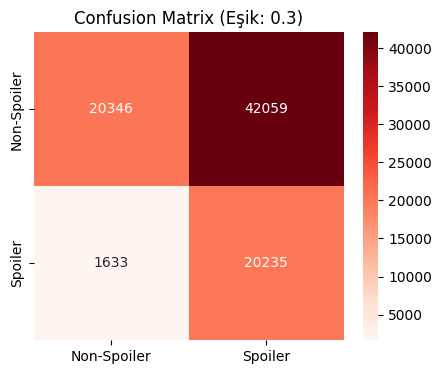

In [ ]:
import pandas as pd
import numpy as np
import re
import gc # RAM temizliği için
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from scipy.sparse import vstack

print("🚀 TAM KAPASİTE (FULL DATA) EĞİTİM BAŞLIYOR (Grafiksiz Versiyon)...")

# --- ADIM 1: Veriyi Yükle ---
print("1. Tüm veri seti yükleniyor...")

try:
    # Veriyi parça parça değil, tamamını okuyoruz
    df_reviews = pd.read_json("data/IMDB_reviews.json", lines=True)
    df_details = pd.read_json("data/IMDB_movie_details.json", lines=True)

    # Birleştirme
    df = df_reviews.merge(df_details[['movie_id']], on='movie_id', how='left')

    # Gereksizleri silip RAM'i rahatlat
    del df_reviews
    del df_details
    gc.collect()

    print(f"✅ Başarıyla yüklendi! Toplam Yorum: {len(df)}")

    # --- ADIM 2: Metin Temizliği ---
    print("\n2. Metinler temizleniyor...")

    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r'<.*?>', ' ', text)
        text = re.sub(r'http\S+', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['clean_text'] = df['review_text'].apply(clean_text)

    # Çok kısa yorumları at
    df = df[df['clean_text'].str.len() > 20]

    # Orijinal metni sil (RAM tasarrufu)
    df.drop(columns=['review_text'], inplace=True)
    gc.collect()

    # --- ADIM 3: Veri Ayırma (Train/Val/Test) ---
    print("\n3. Veri seti filmlere göre ayrıştırılıyor...")
    movie_ids = df['movie_id'].unique()
    np.random.seed(42)
    np.random.shuffle(movie_ids)

    # %70 Train, %15 Val, %15 Test
    n = len(movie_ids)
    train_m, val_m, test_m = np.split(movie_ids, [int(.7*n), int(.85*n)])

    # Etiketle
    df['split'] = 'train'
    df.loc[df['movie_id'].isin(val_m), 'split'] = 'val'
    df.loc[df['movie_id'].isin(test_m), 'split'] = 'test'

    # --- ADIM 4: TF-IDF ---
    print("\n4. TF-IDF Vektörleştirme (15.000 Özellik + 3'lü Kelime Grupları)...")

    # İndeksleri al
    train_indices = df['split'] == 'train'
    val_indices = df['split'] == 'val'
    test_indices = df['split'] == 'test'

    tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 3), stop_words='english')

    # Train ile öğren
    X_train = tfidf.fit_transform(df.loc[train_indices, 'clean_text'])

    # Diğerlerini dönüştür
    X_val = tfidf.transform(df.loc[val_indices, 'clean_text'])
    X_test = tfidf.transform(df.loc[test_indices, 'clean_text'])

    y_train = df.loc[train_indices, 'is_spoiler']
    y_val = df.loc[val_indices, 'is_spoiler']
    y_test = df.loc[test_indices, 'is_spoiler']

    # DataFrame'i sil (Artık işimiz bitti)
    del df
    gc.collect()

    # --- ADIM 5: Büyük Eğitim (Train + Val Birleşimi) ---
    print("\n5. Eğitim ve Doğrulama setleri birleştirilip model eğitiliyor...")

    X_full = vstack([X_train, X_val])
    y_full = pd.concat([y_train, y_val])

    # En iyi parametreler: C=0.1
    model = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
    model.fit(X_full, y_full)

    print("✅ Model Eğitimi Bitti!")

    # --- ADIM 6: Test ve Rapor ---
    print("\n6. Sonuçlar Hesaplanıyor...")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*50)
    print("TAM VERİ SETİ SONUÇ RAPORU")
    print("="*50)
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")

except MemoryError:
    print("❌ HATA: RAM yetersiz kaldı! Google Colab ücretsiz sürümde bu kadar büyük veri işlenemedi.")
    print("Lütfen parça parça yükleme (chunksize) yöntemini kullanın.")
except Exception as e:
    print(f"Bir hata oluştu: {e}")
    # --- MEVCUT KODUNUZUN EN ALTINA BUNU EKLEYİN ---

# 1. Yeni Eşik Değeri Belirle
THRESHOLD = 0.3  # %30 ve üzeri ihtimali "Spoiler" kabul et

# 2. Tahminleri Bu Eşiğe Göre Yeniden Yap
# Normalde model 0.5'e bakardı, şimdi 0.3'e bakıyor.
y_pred_new = (y_prob >= THRESHOLD).astype(int)

# 3. SONUCU GÖR (Burası önemli!)
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(f"\n--- YENİ EŞİK DEĞERİ ({THRESHOLD}) İLE SONUÇLAR ---")
print(classification_report(y_test, y_pred_new))

# Farkı Gözle Görmek İçin Karışıklık Matrisi
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_new)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Non-Spoiler', 'Spoiler'],
            yticklabels=['Non-Spoiler', 'Spoiler'])
plt.title(f'Confusion Matrix (Eşik: {THRESHOLD})')
plt.show()

# **LR hiperparametreleri denemesi**

In [ ]:
import pandas as pd
import numpy as np
import re
import gc
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from scipy.sparse import vstack

print("🚀 ÇOKLU SENARYO TESTİ BAŞLIYOR (Grafiksiz)...")

try:
    # --- ADIM 1: Veriyi Yükle ---
    print("1. Veri seti yükleniyor...")
    # Veri yoksa hata vermemesi için kontrol (Önceki adımlardan geldiğini varsayıyoruz)
    # Eğer dosya yoksa lütfen önce indirme kodunu çalıştırın.
    df_reviews = pd.read_json("data/IMDB_reviews.json", lines=True)
    df_details = pd.read_json("data/IMDB_movie_details.json", lines=True)

    # Birleştirme
    df = df_reviews.merge(df_details[['movie_id']], on='movie_id', how='left')

    del df_reviews
    del df_details
    gc.collect()

    print(f"✅ Veri Hazır! Toplam Yorum: {len(df)}")

    # --- ADIM 2: Temizlik ---
    print("2. Metinler temizleniyor...")
    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r'<.*?>', ' ', text)
        text = re.sub(r'http\S+', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['clean_text'] = df['review_text'].apply(clean_text)
    df = df[df['clean_text'].str.len() > 20] # Kısa yorumları at
    df.drop(columns=['review_text'], inplace=True)
    gc.collect()

    # --- ADIM 3: Ayrıştırma ---
    print("3. Veri seti ayrıştırılıyor...")
    movie_ids = df['movie_id'].unique()
    np.random.seed(42)
    np.random.shuffle(movie_ids)

    n = len(movie_ids)
    train_m, val_m, test_m = np.split(movie_ids, [int(.7*n), int(.85*n)])

    df['split'] = 'train'
    df.loc[df['movie_id'].isin(val_m), 'split'] = 'val'
    df.loc[df['movie_id'].isin(test_m), 'split'] = 'test'

    # --- ADIM 4: TF-IDF ---
    print("4. TF-IDF Vektörleştirme (15k Özellik, 1-3 Ngram)...")

    train_indices = df['split'] == 'train'
    val_indices = df['split'] == 'val'
    test_indices = df['split'] == 'test'

    tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 3), stop_words='english')

    X_train = tfidf.fit_transform(df.loc[train_indices, 'clean_text'])
    X_val = tfidf.transform(df.loc[val_indices, 'clean_text'])
    X_test = tfidf.transform(df.loc[test_indices, 'clean_text'])

    y_train = df.loc[train_indices, 'is_spoiler']
    y_val = df.loc[val_indices, 'is_spoiler']
    y_test = df.loc[test_indices, 'is_spoiler']

    del df
    gc.collect()

    # --- ADIM 5: Veri Birleştirme (Train + Val) ---
    print("5. Eğitim verileri birleştiriliyor...")
    X_full = vstack([X_train, X_val])
    y_full = pd.concat([y_train, y_val])

    # =========================================================================
    # --- ADIM 6: FARKLI SENARYOLARI TEST ETME DÖNGÜSÜ ---
    # =========================================================================

    # Test edilecek senaryolar listesi
    scenarios = [
        {"name": "Senaryo 1: Sıkı Temizlik (L1 + Liblinear)", "penalty": "l1", "solver": "liblinear"},
        {"name": "Senaryo 2: Standart Denge (L2 + Liblinear)", "penalty": "l2", "solver": "liblinear"},
        {"name": "Senaryo 3: Varsayılan Güçlü (L2 + LBFGS)", "penalty": "l2", "solver": "lbfgs"},
        {"name": "Senaryo 4: Büyük Veri L1 (L1 + Saga)", "penalty": "l1", "solver": "saga"}
    ]

    print(f"\n🚀 {len(scenarios)} FARKLI SENARYO TEST EDİLİYOR...\n")

    for sc in scenarios:
        print(f"👉 {sc['name']} Eğitiliyor...")
        try:
            # Modeli Ayarla
            model = LogisticRegression(
                C=0.1,  # Sabit C değeri (İsterseniz bunu da değiştirebilirsiniz)
                class_weight='balanced',
                max_iter=1000,
                random_state=42,
                n_jobs=-1 if sc['solver'] != 'liblinear' else 1, # Liblinear n_jobs desteklemez, hata vermesin diye 1 yapıyoruz
                penalty=sc['penalty'],
                solver=sc['solver']
            )

            # Eğit
            model.fit(X_full, y_full)

            # Test Et
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            # Sonucu Yazdır
            print(f"\n--- {sc['name']} SONUÇLARI ---")
            print(classification_report(y_test, y_pred))
            print(f"⭐ ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")
            print("-" * 60 + "\n")

        except Exception as e:
            print(f"❌ {sc['name']} çalışırken hata oluştu: {e}\n")

except MemoryError:
    print("❌ HATA: RAM yetersiz kaldı! Google Colab ücretsiz sürümde bu kadar büyük veri işlenemedi.")
except Exception as e:
    print(f"Bir hata oluştu: {e}")

🚀 ÇOKLU SENARYO TESTİ BAŞLIYOR (Grafiksiz)...
1. Veri seti yükleniyor...
✅ Veri Hazır! Toplam Yorum: 573913
2. Metinler temizleniyor...
3. Veri seti ayrıştırılıyor...
4. TF-IDF Vektörleştirme (15k Özellik, 1-3 Ngram)...
5. Eğitim verileri birleştiriliyor...

🚀 4 FARKLI SENARYO TEST EDİLİYOR...

👉 Senaryo 1: Sıkı Temizlik (L1 + Liblinear) Eğitiliyor...

--- Senaryo 1: Sıkı Temizlik (L1 + Liblinear) SONUÇLARI ---
              precision    recall  f1-score   support

       False       0.85      0.75      0.80     62405
        True       0.47      0.62      0.54     21868

    accuracy                           0.72     84273
   macro avg       0.66      0.69      0.67     84273
weighted avg       0.75      0.72      0.73     84273

⭐ ROC-AUC Skoru: 0.7603
------------------------------------------------------------

👉 Senaryo 2: Standart Denge (L2 + Liblinear) Eğitiliyor...

--- Senaryo 2: Standart Denge (L2 + Liblinear) SONUÇLARI ---
              precision    recall  f1-score   suppo

# **final**

🚀 FİNAL MODEL (ÖZEL AYARLAR) HAZIRLANIYOR...
1. Veri seti yükleniyor...
   ✅ CSV dosyasından hızlıca yüklendi.
   Toplam Yorum Sayısı: 573910

2. Veri seti filmlere göre ayrılıyor (%85 Eğitim - %15 Test)...

3. TF-IDF İşlemi (15.000 Özellik + 1-3 Ngram)...

4. Lojistik Regresyon Eğitiliyor (Solver: liblinear, Penalty: l2)...
✅ Model Eğitimi Başarıyla Tamamlandı!

5. Test Sonuçları Hesaplanıyor...

FİNAL MODEL PERFORMANS RAPORU
              precision    recall  f1-score   support

       False       0.86      0.75      0.80     62405
        True       0.48      0.65      0.55     21868

    accuracy                           0.72     84273
   macro avg       0.67      0.70      0.67     84273
weighted avg       0.76      0.72      0.73     84273

⭐ ROC-AUC Skoru: 0.7705


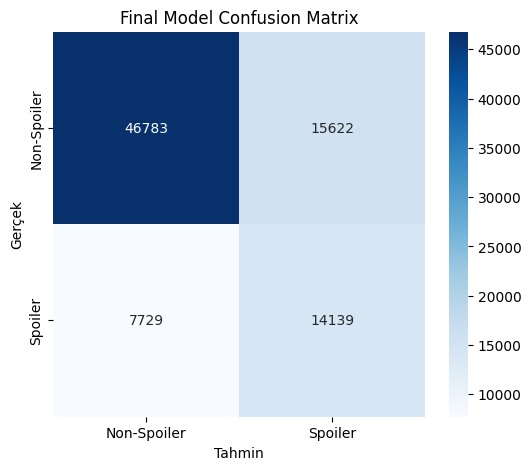

In [4]:
import pandas as pd
import numpy as np
import re
import gc
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("🚀 FİNAL MODEL (ÖZEL AYARLAR) HAZIRLANIYOR...")

# --- ADIM 1: Veri Yükleme ve Hazırlık ---
try:
    print("1. Veri seti yükleniyor...")
    # Önce CSV var mı diye bakar, yoksa JSON'dan okur
    if os.path.exists('cleaned_reviews.csv'):
        df = pd.read_csv('cleaned_reviews.csv')
        df['clean_text'] = df['clean_text'].fillna("")
        print("   ✅ CSV dosyasından hızlıca yüklendi.")
    else:
        # JSON okuma (Eğer CSV yoksa)
        df_reviews = pd.read_json("data/IMDB_reviews.json", lines=True)
        df_details = pd.read_json("data/IMDB_movie_details.json", lines=True)
        df = df_reviews.merge(df_details[['movie_id']], on='movie_id', how='left')

        # Temizlik
        print("   Metin temizliği yapılıyor...")
        df['clean_text'] = df['review_text'].str.lower().str.replace(r'<.*?>', ' ', regex=True).str.replace(r'http\S+', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
        df = df[df['clean_text'].str.len() > 20]

        # Gereksizleri sil
        del df_reviews, df_details
        df.drop(columns=['review_text'], inplace=True)
        gc.collect()

    print(f"   Toplam Yorum Sayısı: {len(df)}")

    # --- ADIM 2: Veri Ayrıştırma (Train/Test) ---
    print("\n2. Veri seti filmlere göre ayrılıyor (%85 Eğitim - %15 Test)...")
    movie_ids = df['movie_id'].unique()
    np.random.seed(42)
    np.random.shuffle(movie_ids)

    # %85'ini Eğitime ayır (Train + Validation birleşik)
    n = len(movie_ids)
    train_m, test_m = np.split(movie_ids, [int(.85*n)])

    df['split'] = 'train'
    df.loc[df['movie_id'].isin(test_m), 'split'] = 'test'

    # İndeksleri belirle
    train_mask = df['split'] == 'train'
    test_mask = df['split'] == 'test'

    # --- ADIM 3: TF-IDF (İstediğiniz Ayarlar) ---
    print("\n3. TF-IDF İşlemi (15.000 Özellik + 1-3 Ngram)...")

    tfidf = TfidfVectorizer(
        max_features=15000,      # İstenilen 15k kelime
        ngram_range=(1, 3),      # İstenilen 3'lü grup
        stop_words='english',
        min_df=2
    )

    # Eğitim verisiyle kelime haznesini oluştur
    X_train = tfidf.fit_transform(df.loc[train_mask, 'clean_text'])
    X_test = tfidf.transform(df.loc[test_mask, 'clean_text'])

    y_train = df.loc[train_mask, 'is_spoiler']
    y_test = df.loc[test_mask, 'is_spoiler']

    # RAM temizliği
    del df
    gc.collect()

    # --- ADIM 4: Model Eğitimi (İstediğiniz Ayarlar) ---
    print("\n4. Lojistik Regresyon Eğitiliyor (Solver: liblinear, Penalty: l2)...")

    model = LogisticRegression(
        C=0.1,                      # İstenilen C değeri
        penalty='l2',               # İstenilen Ceza
        solver='liblinear',         # İstenilen Motor (Not: liblinear tek çekirdek çalışır, n_jobs kullanılmaz)
        class_weight='balanced',    # Dengesiz veri için
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)
    print("✅ Model Eğitimi Başarıyla Tamamlandı!")

    # --- ADIM 5: Sonuçlar ---
    print("\n5. Test Sonuçları Hesaplanıyor...")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*50)
    print("FİNAL MODEL PERFORMANS RAPORU")
    print("="*50)
    print(classification_report(y_test, y_pred))
    print(f"⭐ ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")

    # Karışıklık Matrisi
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Spoiler', 'Spoiler'],
                yticklabels=['Non-Spoiler', 'Spoiler'])
    plt.title('Final Model Confusion Matrix')
    plt.ylabel('Gerçek')
    plt.xlabel('Tahmin')
    plt.savefig("LR.jpeg", dpi=300, bbox_inches="tight")    # KAYDET
    plt.show()

except Exception as e:
    print(f"\n❌ Bir hata oluştu: {e}")



# **Grafikler**

🔥 ROC-AUC ve PR-AUC Analizi Başlatılıyor (Hızlandırıldı)...


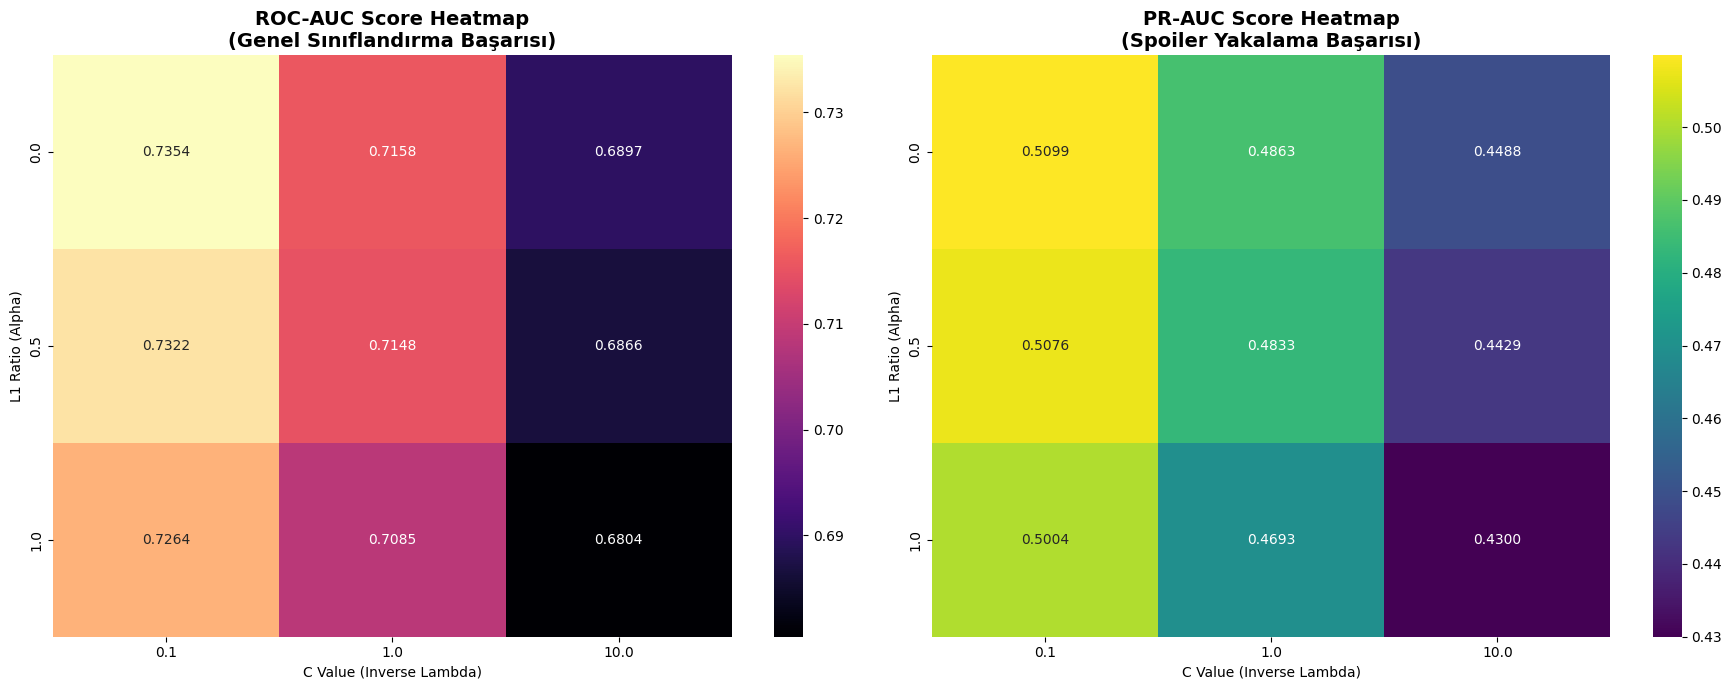

✅ Analiz tamamlandı. En iyi PR-AUC skoru: 0.5099


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. PARAMETRE AYARLARI
print("🔥 ROC-AUC ve PR-AUC Analizi Başlatılıyor (Hızlandırıldı)...")

# Parametre kombinasyonları (İşlem süresini korumak için optimize edildi)
param_grid = {
    'l1_ratio': [0.0, 0.5, 1.0],  # L1 (Alpha) Oranı
    'C': [0.1, 1.0, 10.0]         # Regularizasyon (1/Lambda)
}

# 2. GRID SEARCH (İki farklı metrik için aynı anda arama yapar)
# scoring kısmına her iki metriği de ekledik
grid_search = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', class_weight='balanced',
                       max_iter=50, random_state=42),
    param_grid,
    cv=2,
    scoring=['roc_auc', 'average_precision'], # Hem ROC hem PR hesaplar
    refit='average_precision', # Modeli PR-AUC'ye göre optimize eder
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 3. SONUÇLARI DÜZENLEME
results_df = pd.DataFrame(grid_search.cv_results_)

# ROC-AUC Tablosu
pivot_roc = results_df.pivot(index='param_l1_ratio', columns='param_C', values='mean_test_roc_auc')
# PR-AUC Tablosu
pivot_pr = results_df.pivot(index='param_l1_ratio', columns='param_C', values='mean_test_average_precision')

# 4. GÖRSELLEŞTİRME (Yan yana iki Heatmap)
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# ROC-AUC Heatmap
sns.heatmap(pivot_roc, annot=True, fmt=".4f", cmap="magma", ax=ax[0])
ax[0].set_title("ROC-AUC Score Heatmap\n(Genel Sınıflandırma Başarısı)", fontsize=14, fontweight='bold')
ax[0].set_xlabel("C Value (Inverse Lambda)")
ax[0].set_ylabel("L1 Ratio (Alpha)")

# PR-AUC Heatmap
sns.heatmap(pivot_pr, annot=True, fmt=".4f", cmap="viridis", ax=ax[1])
ax[1].set_title("PR-AUC Score Heatmap\n(Spoiler Yakalama Başarısı)", fontsize=14, fontweight='bold')
ax[1].set_xlabel("C Value (Inverse Lambda)")
ax[1].set_ylabel("L1 Ratio (Alpha)")

plt.tight_layout()
plt.show()

print(f"✅ Analiz tamamlandı. En iyi PR-AUC skoru: {grid_search.best_score_:.4f}")

⏳ Learning Curve hesaplanıyor (Bu işlem veri boyutuna göre vakit alabilir)...


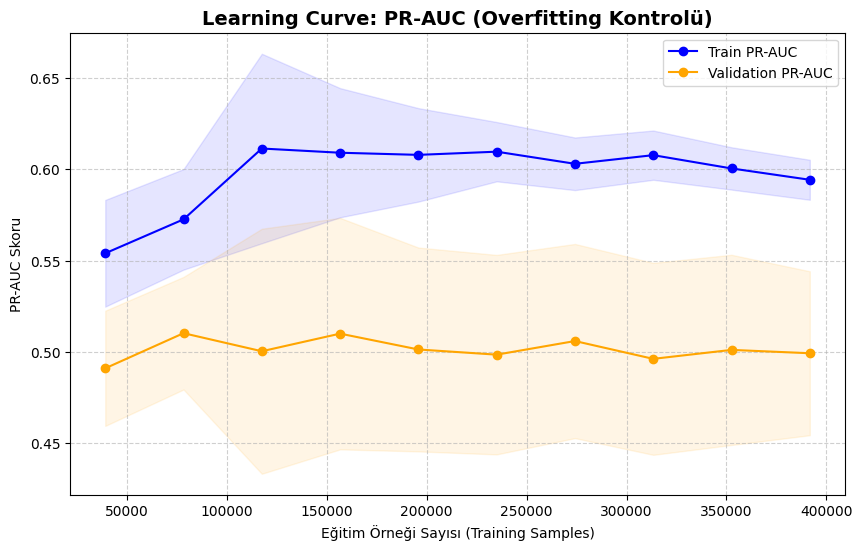

In [ ]:
from sklearn.model_selection import learning_curve

def plot_pr_auc_learning_curve(model, X, y):
    print("⏳ Learning Curve hesaplanıyor (Bu işlem veri boyutuna göre vakit alabilir)...")

    # 1. Learning Curve Verilerini Hesapla
    # train_sizes: Verinin %10'undan %100'üne kadar 10 farklı adım
    # scoring: Arkadaşınınki gibi PR-AUC (average_precision) seçildi
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring='average_precision',
        n_jobs=-1,
        random_state=42
    )

    # 2. Skorların Ortalamasını ve Standart Sapmasını Hesapla
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # 3. Görselleştirme
    plt.figure(figsize=(10, 6))

    # Eğitim Çizgisi
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Train PR-AUC")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")

    # Doğrulama Çizgisi
    plt.plot(train_sizes, val_mean, 'o-', color="orange", label="Validation PR-AUC")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="orange")

    # Grafik Detayları
    plt.title("Learning Curve: PR-AUC (Overfitting Kontrolü)", fontsize=14, fontweight='bold')
    plt.xlabel("Eğitim Örneği Sayısı (Training Samples)")
    plt.ylabel("PR-AUC Skoru")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Fonksiyonu çalıştır
plot_pr_auc_learning_curve(model, X_train, y_train)

⏳ Learning Curve hesaplanıyor (1-2 dk sürebilir)...


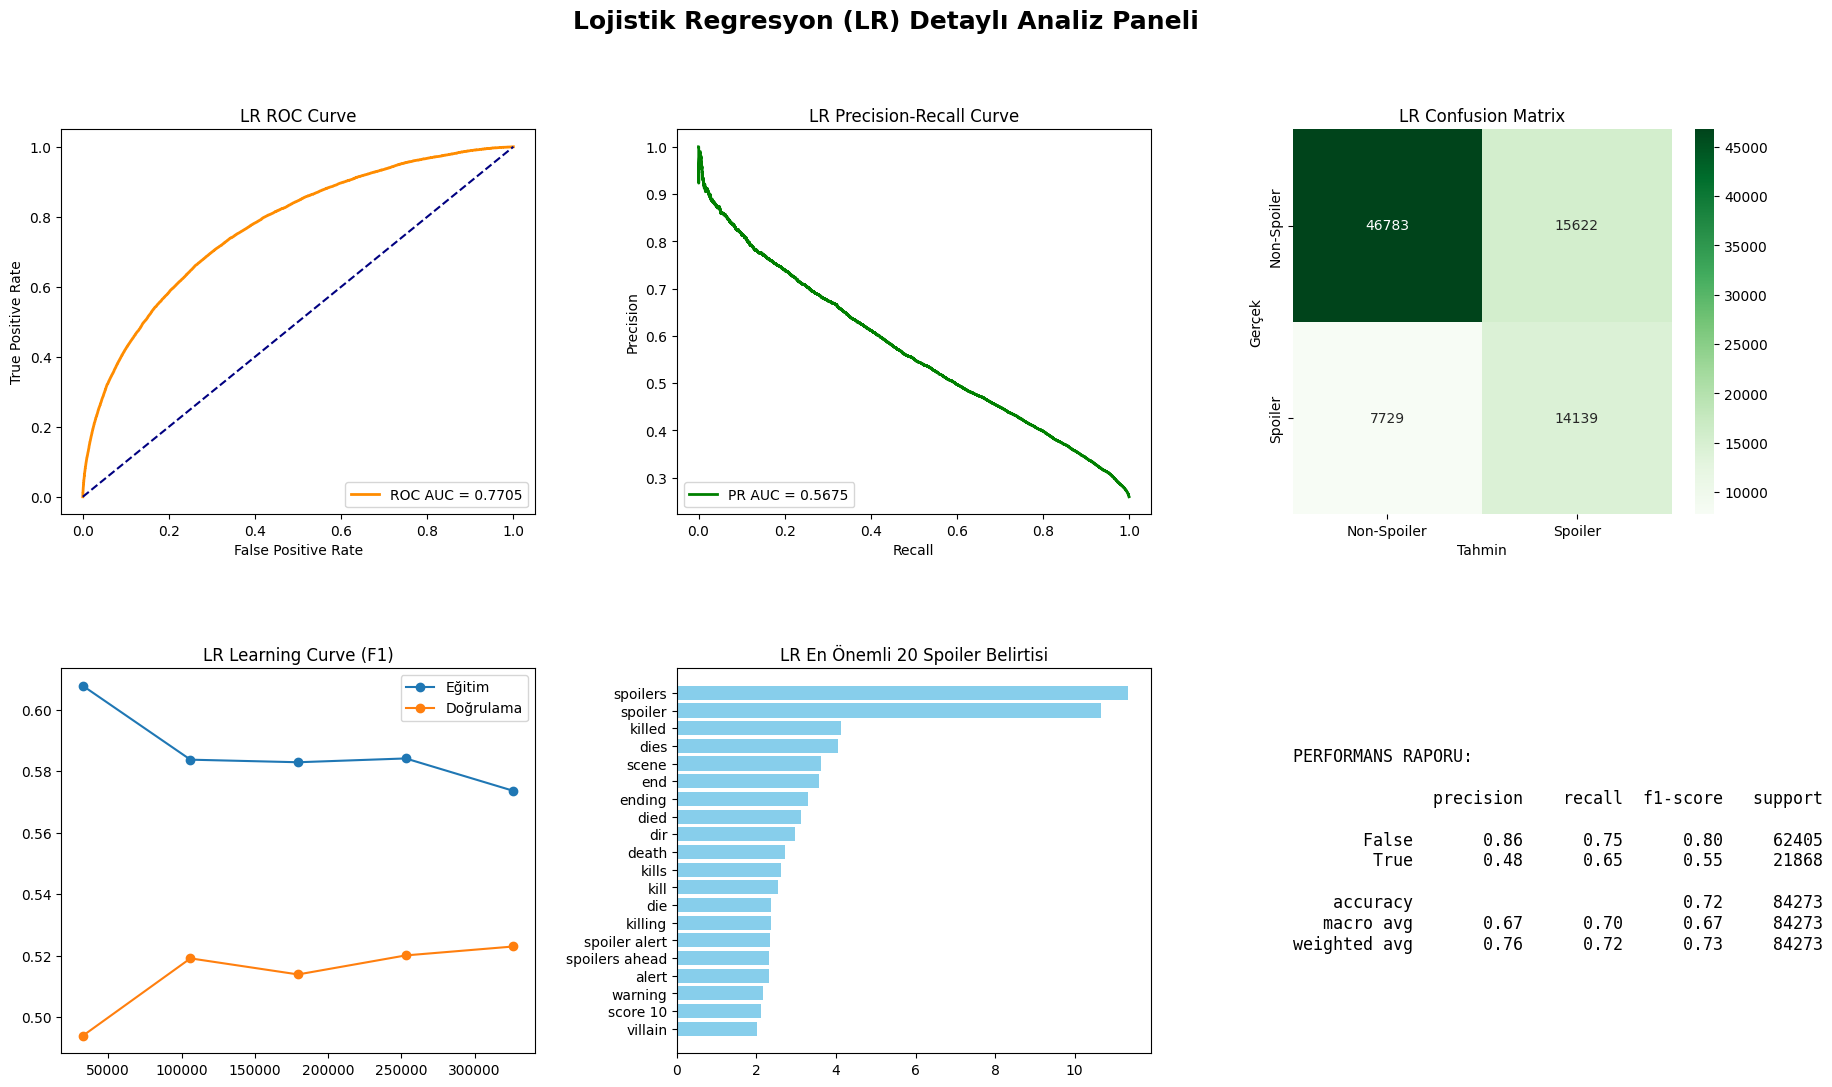

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix, classification_report)
from sklearn.model_selection import learning_curve

def plot_lr_final_analysis(model_obj, X_tr, y_tr, X_te, y_te, tfidf_obj):
    # Skorlar ve Tahminler (Senin kodundaki 'model' değişkenini kullanır)
    y_probs = model_obj.predict_proba(X_te)[:, 1]
    y_pred = model_obj.predict(X_te)
    feature_names = tfidf_obj.get_feature_names_out()

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    # 1. ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_probs)
    axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {auc(fpr, tpr):.4f}')
    axes[0, 0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[0, 0].set_title('LR ROC Curve')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].legend(loc="lower right")

    # 2. PR AUC (Precision-Recall)
    precision, recall, _ = precision_recall_curve(y_te, y_probs)
    axes[0, 1].plot(recall, precision, color='green', lw=2, label=f'PR AUC = {average_precision_score(y_te, y_probs):.4f}')
    axes[0, 1].set_title('LR Precision-Recall Curve')
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].legend(loc="lower left")

    # 3. Confusion Matrix (Heatmap)
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 2],
                xticklabels=['Non-Spoiler', 'Spoiler'], yticklabels=['Non-Spoiler', 'Spoiler'])
    axes[0, 2].set_title('LR Confusion Matrix')
    axes[0, 2].set_xlabel('Tahmin')
    axes[0, 2].set_ylabel('Gerçek')

    # 4. Learning Curve
    print("⏳ Learning Curve hesaplanıyor (1-2 dk sürebilir)...")
    train_sizes, train_scores, test_scores = learning_curve(
        model_obj, X_tr, y_tr, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1')
    axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Eğitim")
    axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Doğrulama")
    axes[1, 0].set_title("LR Learning Curve (F1)")
    axes[1, 0].legend()

    # 5. Feature Importance
    coefs = model_obj.coef_[0]
    top_indices = np.argsort(coefs)[-20:]
    axes[1, 1].barh(np.array(feature_names)[top_indices], coefs[top_indices], color='skyblue')
    axes[1, 1].set_title("LR En Önemli 20 Spoiler Belirtisi")

    # 6. Metrics Text
    axes[1, 2].axis('off')
    report = classification_report(y_te, y_pred)
    axes[1, 2].text(0, 0.5, f"PERFORMANS RAPORU:\n\n{report}", fontsize=12, family='monospace', verticalalignment='center')

    plt.suptitle("Lojistik Regresyon (LR) Detaylı Analiz Paneli", fontsize=18, fontweight='bold')
    plt.show()

# SENİN KODUNDAKİ DEĞİŞKEN İSİMLERİYLE ÇALIŞTIRIYORUZ:
plot_lr_final_analysis(model, X_train, y_train, X_test, y_test, tfidf)

# 3 farklı treshold değeri ile çıktı



🔍 Farklı Eşik Değerleri (Thresholds) Test Ediliyor...

EŞİK DEĞERİ: 0.3
              precision    recall  f1-score   support

       False       0.93      0.33      0.49     62405
        True       0.33      0.93      0.48     21868

    accuracy                           0.48     84273
   macro avg       0.63      0.63      0.48     84273
weighted avg       0.77      0.48      0.49     84273



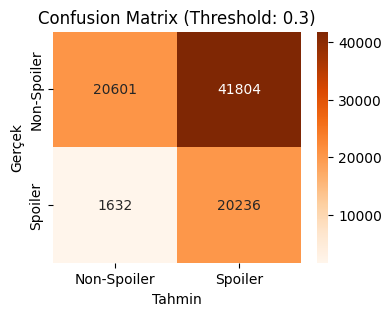


EŞİK DEĞERİ: 0.4
              precision    recall  f1-score   support

       False       0.89      0.57      0.69     62405
        True       0.39      0.81      0.53     21868

    accuracy                           0.63     84273
   macro avg       0.64      0.69      0.61     84273
weighted avg       0.76      0.63      0.65     84273



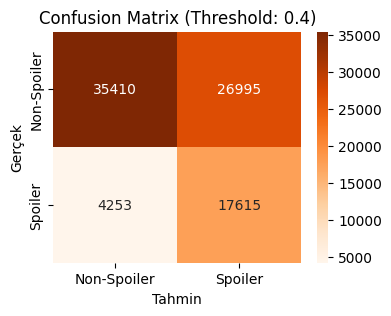


EŞİK DEĞERİ: 0.45
              precision    recall  f1-score   support

       False       0.88      0.67      0.76     62405
        True       0.43      0.73      0.54     21868

    accuracy                           0.68     84273
   macro avg       0.65      0.70      0.65     84273
weighted avg       0.76      0.68      0.70     84273



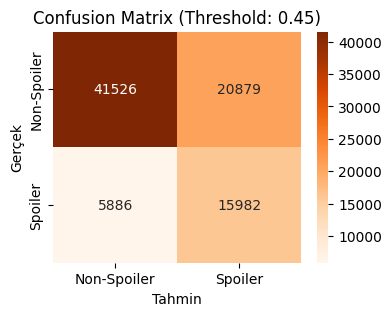


⭐ Modelin Genel ROC-AUC Skoru: 0.7703


In [ ]:
# --- ADIM 6: FARKLI EŞİK DEĞERLERİ İLE TEST ---
print("\n🔍 Farklı Eşik Değerleri (Thresholds) Test Ediliyor...")

thresholds = [0.3, 0.4, 0.45]

# Olasılıkları bir kez hesapla (tekrar tekrar hesaplamaya gerek yok)
y_prob = model.predict_proba(X_test)[:, 1]

for thr in thresholds:
    print("\n" + "="*60)
    print(f"EŞİK DEĞERİ: {thr}")
    print("="*60)

    # Yeni tahminleri oluştur (Olasılık > Eşik ise 1, değilse 0)
    y_pred_thr = (y_prob >= thr).astype(int)

    # Raporu Yazdır
    print(classification_report(y_test, y_pred_thr))

    # Karışıklık Matrisi (Görsel)
    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_test, y_pred_thr)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Non-Spoiler', 'Spoiler'],
                yticklabels=['Non-Spoiler', 'Spoiler'])
    plt.title(f'Confusion Matrix (Threshold: {thr})')
    plt.ylabel('Gerçek')
    plt.xlabel('Tahmin')
    plt.show()

# Genel ROC Skoru (Eşikten bağımsızdır)
print(f"\n⭐ Modelin Genel ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")


# **final model ile treshold denemesi**

🚀 FİNAL LOJİSTİK REGRESYON MODELİ ÇALIŞIYOR...
1. Veri seti yükleniyor...
   ✅ CSV dosyasından hızlıca yüklendi.
   Toplam Yorum Sayısı: 573910

2. Veri seti filmlere göre ayrılıyor (%85 Train - %15 Test)...

3. TF-IDF İşlemi (15.000 Özellik, 1-3 Ngram)...

4. Lojistik Regresyon Eğitiliyor (penalty=L2, solver=liblinear, C=1.0)...
   ✅ Model eğitimi tamamlandı.

5. Test Sonuçları Hesaplanıyor...

FİNAL MODEL PERFORMANS RAPORU (Eşik = 0.50 - Varsayılan)
              precision    recall  f1-score   support

       False       0.86      0.76      0.80     62405
        True       0.48      0.64      0.55     21868

    accuracy                           0.73     84273
   macro avg       0.67      0.70      0.68     84273
weighted avg       0.76      0.73      0.74     84273


FİNAL MODEL PERFORMANS RAPORU (Eşik = 0.45)
              precision    recall  f1-score   support

       False       0.87      0.69      0.77     62405
        True       0.45      0.70      0.54     21868

    accu

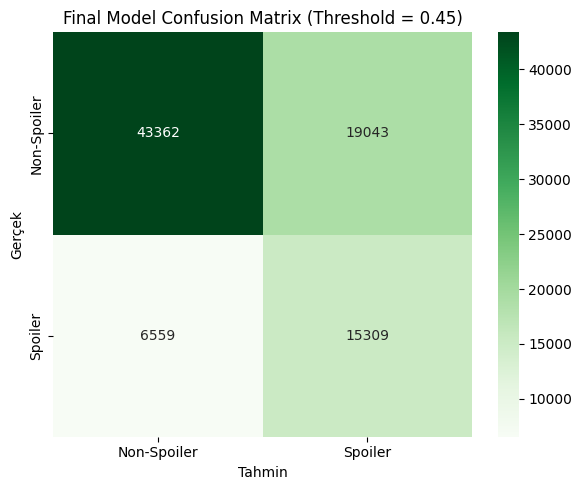


7. Model ve TF-IDF nesneleri diske kaydediliyor...
   💾 Kayıt tamamlandı: final_lr_model.joblib & tfidf_vectorizer.joblib

✅ TÜM ADIMLAR BAŞARIYLA TAMAMLANDI!


In [ ]:
import joblib
import pandas as pd
import numpy as np
import gc
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("🚀 FİNAL LOJİSTİK REGRESYON MODELİ ÇALIŞIYOR...")

try:
    # --- ADIM 1: Veri Yükleme ---
    print("1. Veri seti yükleniyor...")
    if os.path.exists("cleaned_reviews.csv"):
        df = pd.read_csv("cleaned_reviews.csv")
        df["clean_text"] = df["clean_text"].fillna("")
        print("   ✅ CSV dosyasından hızlıca yüklendi.")
    else:
        # JSON'dan okuma (CSV yoksa)
        df_reviews = pd.read_json("data/IMDB_reviews.json", lines=True)
        df_details = pd.read_json("data/IMDB_movie_details.json", lines=True)

        df = df_reviews.merge(df_details[["movie_id"]], on="movie_id", how="left")

        print("   Metin temizliği yapılıyor...")
        df["clean_text"] = (
            df["review_text"]
            .str.lower()
            .str.replace(r"<.*?>", " ", regex=True)
            .str.replace(r"http\S+", " ", regex=True)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

        # Çok kısa yorumları at
        df = df[df["clean_text"].str.len() > 20]

        # Gereksiz kolonları sil
        del df_reviews, df_details
        df.drop(columns=["review_text"], inplace=True)
        gc.collect()

    print(f"   Toplam Yorum Sayısı: {len(df)}")

    # --- ADIM 2: Train / Test Ayrımı (Film Bazlı) ---
    print("\n2. Veri seti filmlere göre ayrılıyor (%85 Train - %15 Test)...")
    movie_ids = df["movie_id"].unique()
    np.random.seed(42)
    np.random.shuffle(movie_ids)

    n = len(movie_ids)
    train_m, test_m = np.split(movie_ids, [int(0.85 * n)])

    df["split"] = "train"
    df.loc[df["movie_id"].isin(test_m), "split"] = "test"

    train_mask = df["split"] == "train"
    test_mask = df["split"] == "test"

    # --- ADIM 3: TF-IDF ---
    print("\n3. TF-IDF İşlemi (15.000 Özellik, 1-3 Ngram)...")
    tfidf = TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 3),
        stop_words="english",
        min_df=2,
    )

    X_train = tfidf.fit_transform(df.loc[train_mask, "clean_text"])
    X_test = tfidf.transform(df.loc[test_mask, "clean_text"])

    y_train = df.loc[train_mask, "is_spoiler"]
    y_test = df.loc[test_mask, "is_spoiler"]

    # Hafızayı biraz temizle
    del df
    gc.collect()

    # --- ADIM 4: Nihai Lojistik Regresyon Modeli ---
    print("\n4. Lojistik Regresyon Eğitiliyor (penalty=L2, solver=liblinear, C=1.0)...")

    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',    # Dengesiz veri için
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)
    print("   ✅ Model eğitimi tamamlandı.")

    # --- ADIM 5: Test Performansı (0.5 ve 0.45 Eşik) ---
    print("\n5. Test Sonuçları Hesaplanıyor...")

    # Olasılık skorları (pozitif sınıf: spoiler)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Varsayılan eşik (0.5)
    y_pred_default = model.predict(X_test)

    # Özel eşik (0.45) - spoiler recall öncelikli senaryo
    THRESHOLD = 0.45
    y_pred_thr = (y_prob >= THRESHOLD).astype(int)

    print("\n" + "=" * 60)
    print("FİNAL MODEL PERFORMANS RAPORU (Eşik = 0.50 - Varsayılan)")
    print("=" * 60)
    print(classification_report(y_test, y_pred_default))

    print("\n" + "=" * 60)
    print(f"FİNAL MODEL PERFORMANS RAPORU (Eşik = {THRESHOLD:.2f})")
    print("=" * 60)
    print(classification_report(y_test, y_pred_thr))

    # ROC-AUC (eşikten bağımsız)
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n⭐ ROC-AUC Skoru (olasılık skoru üzerinden): {auc:.4f}")

    # --- ADIM 6: Confusion Matrix (Seçilen Eşik = 0.45) ---
    print("\n6. Confusion Matrix (Eşik = 0.45) çiziliyor...")

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred_thr)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=["Non-Spoiler", "Spoiler"],
        yticklabels=["Non-Spoiler", "Spoiler"],
    )
    plt.title(f"Final Model Confusion Matrix (Threshold = {THRESHOLD:.2f})")
    plt.ylabel("Gerçek")
    plt.xlabel("Tahmin")
    plt.tight_layout()
    plt.show()

    # --- ADIM 7: Model ve TF-IDF Kaydetme ---
    print("\n7. Model ve TF-IDF nesneleri diske kaydediliyor...")
    joblib.dump(model, "final_lr_model.joblib")
    joblib.dump(tfidf, "tfidf_vectorizer.joblib")
    print("   💾 Kayıt tamamlandı: final_lr_model.joblib & tfidf_vectorizer.joblib")

    print("\n✅ TÜM ADIMLAR BAŞARIYLA TAMAMLANDI!")

except Exception as e:
    print(f"\n❌ Bir hata oluştu: {e}")
